# 1) Imports and Setup

In [1]:
import sys
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import torch
import scipy.cluster.hierarchy as sch
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from adjustText import adjust_text

# Get the absolute path to the project root
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
models_path = os.path.join(project_root, 'models')
sys.path.append(models_path)

from DKT.dkt_model import DKT

# 2) Model and Data Imports


In [2]:
# Load the JSON file
best_config = {'learning_rate': 0.01,
               'model_params':
               {
            "num_skills": 15,
            "num_other": 1,
            "embed_dim": 5,
            "hid_size": 150,
            "num_hid_layers": 1,
            "drop_prob": 0.5
            }
               }


model = DKT(**best_config['model_params'])
model.load_state_dict(torch.load('dkt_synthetic_model.pth', map_location=torch.device('cpu')))
# Set the model to evaluation model
model.eval()


C:\Users\Botond\AppData\Local\Temp\ipykernel_18400\1456610763.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('dkt_synthetic_model.pth'

DKT(
  (embedding): CustomEmbedding(
    (linear): Linear(in_features=15, out_features=5, bias=False)
  )
  (rnn): LSTM(6, 150, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (out): Linear(in_features=150, out_features=15, bias=True)
  (sigmoid): Sigmoid()
)

In [12]:
num_skills = 15

embedding_list = []

# Loop over all skill IDs to generate embeddings
for skill_id in range(num_skills):
    embedding = model.get_embedding(skill_id)
    embedding_list.append(embedding)

df_embeddings = pd.DataFrame(embedding_list, columns=[f"embedding_{i+1}" for i in range(5)], index=[f"skill_{i+1}" for i in range(num_skills)])
df_embeddings['skill_name'] = [1.1,1.2,1.3,1.4,2.1,2.2,2.3,2.4,2.5,3.1,3.2,3.3,3.4,3.5,3.6]

df_embeddings = df_embeddings[df_embeddings['skill_name'].notna()]
print(df_embeddings)

          embedding_1  embedding_2  embedding_3  embedding_4  embedding_5  \
skill_1     -0.164236     0.680581     0.362649    -0.063112     0.189148   
skill_2     -0.122711     0.648311     0.529937    -0.279468     0.529171   
skill_3      0.373643    -0.578097     0.593441    -0.188183     0.479689   
skill_4      0.326553     0.821388     0.572427    -0.697376     0.765837   
skill_5     -0.121186    -0.134718     0.609663    -0.279740     0.989149   
skill_6     -0.265230    -0.282818     0.999967    -0.064321     0.384645   
skill_7     -0.297724    -0.641876     0.804919    -0.017607     0.591776   
skill_8     -0.239373     0.051425     0.888312     0.007623     0.762130   
skill_9     -0.131469     0.160796     0.535800    -0.359719     0.711222   
skill_10    -0.164057     0.269401    -0.739323    -0.359931    -0.230125   
skill_11     0.046931    -0.211419    -0.684146    -0.033514    -0.662136   
skill_12     0.103140    -0.211549    -0.654937     0.283614    -0.696388   

# 3) Visualizations

## 3.1) 3D Visualization


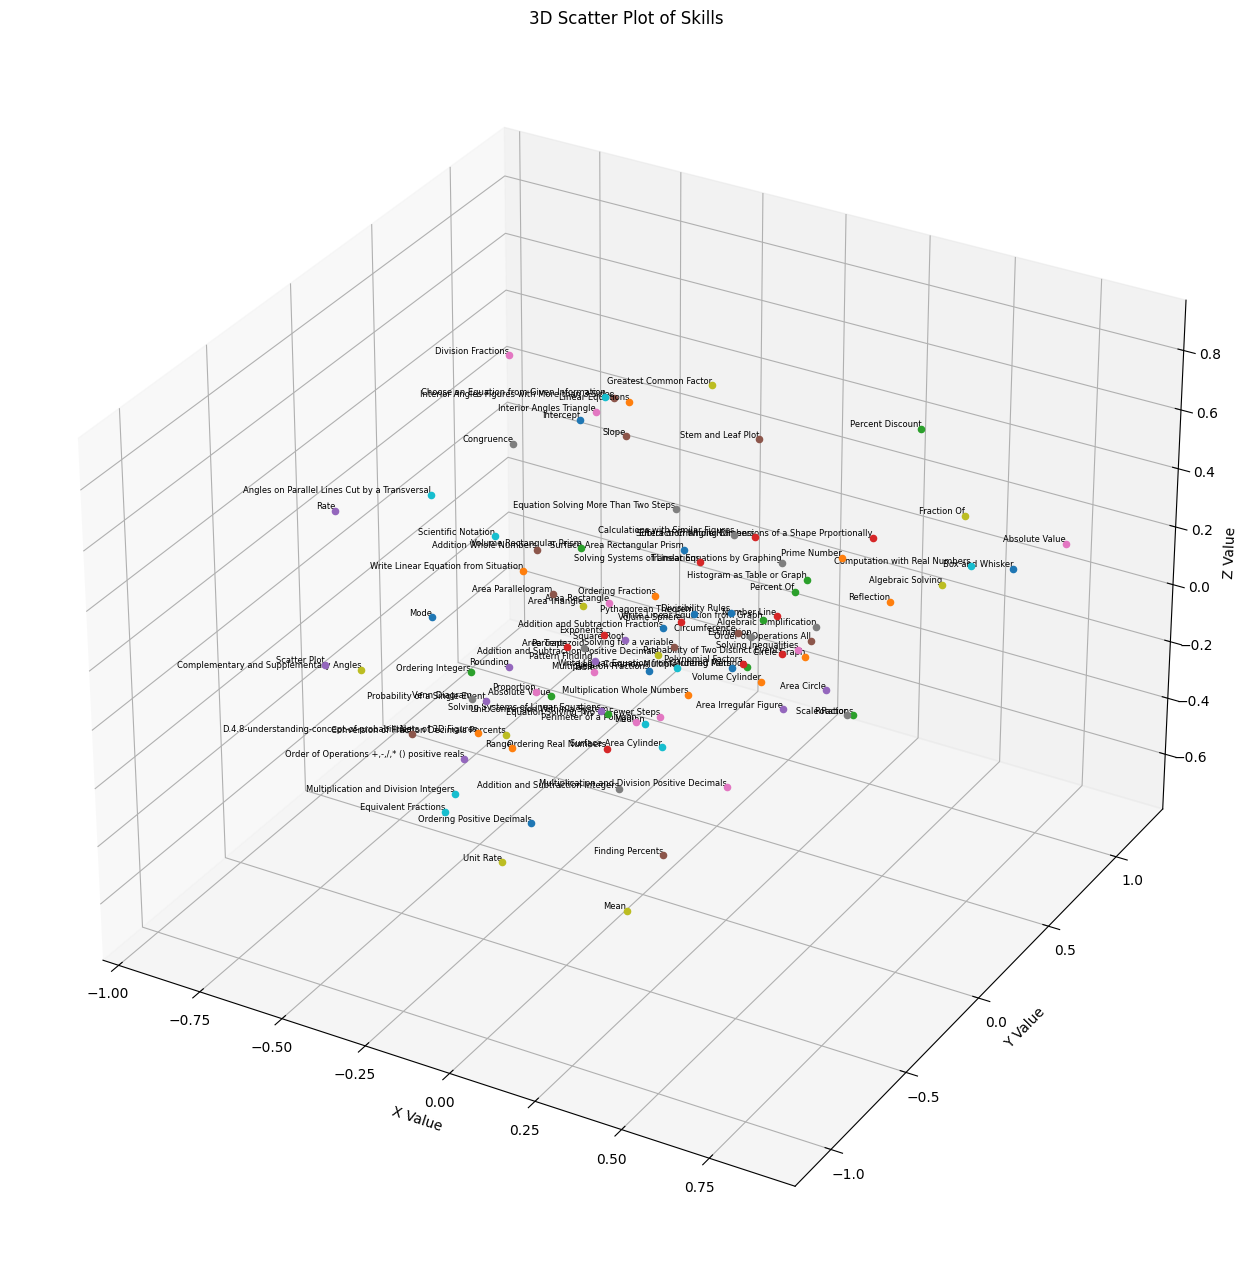

In [5]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')
for i, row in df_embeddings.iterrows():
    ax.scatter(row['embedding_1'], row['embedding_2'], row['embedding_3'])  # 3D coordinates
    ax.text(row['embedding_1'], row['embedding_2'], row['embedding_3'], row['skill_name'], fontsize=6, ha='right', va='bottom')

ax.set_xlabel('X Value')
ax.set_ylabel('Y Value')
ax.set_zlabel('Z Value')
ax.set_title('3D Scatter Plot of Skills')

plt.show()


## 3.2) 2D Visualization

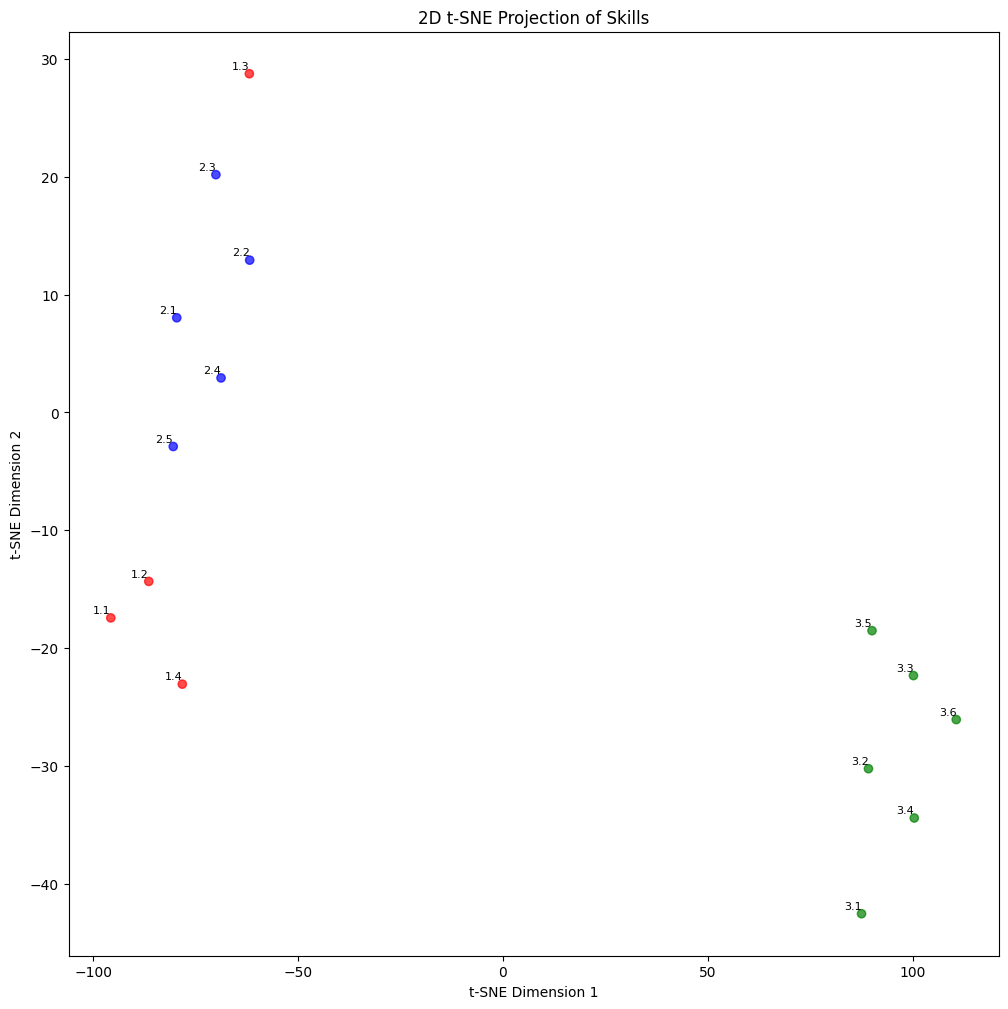

In [16]:
# Perform t-SNE to get to 2D
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
df_embeddings[['tsne_1', 'tsne_2']] = tsne.fit_transform(df_embeddings[['embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5']])

plt.figure(figsize=(12, 12))
colors = 4 * ['red'] + 5 * ['blue'] + 6 * ['green']
plt.scatter(df_embeddings['tsne_1'], df_embeddings['tsne_2'], alpha=0.7, color=colors)

texts = []
for i, row in df_embeddings.iterrows():
        texts.append(plt.text(row['tsne_1'], row['tsne_2'], row['skill_name'], fontsize=8, ha='right', va='bottom'))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('2D t-SNE Projection of Skills')

plt.show()


# 4) Clustering

## 4.1) Hierarchical Clustering

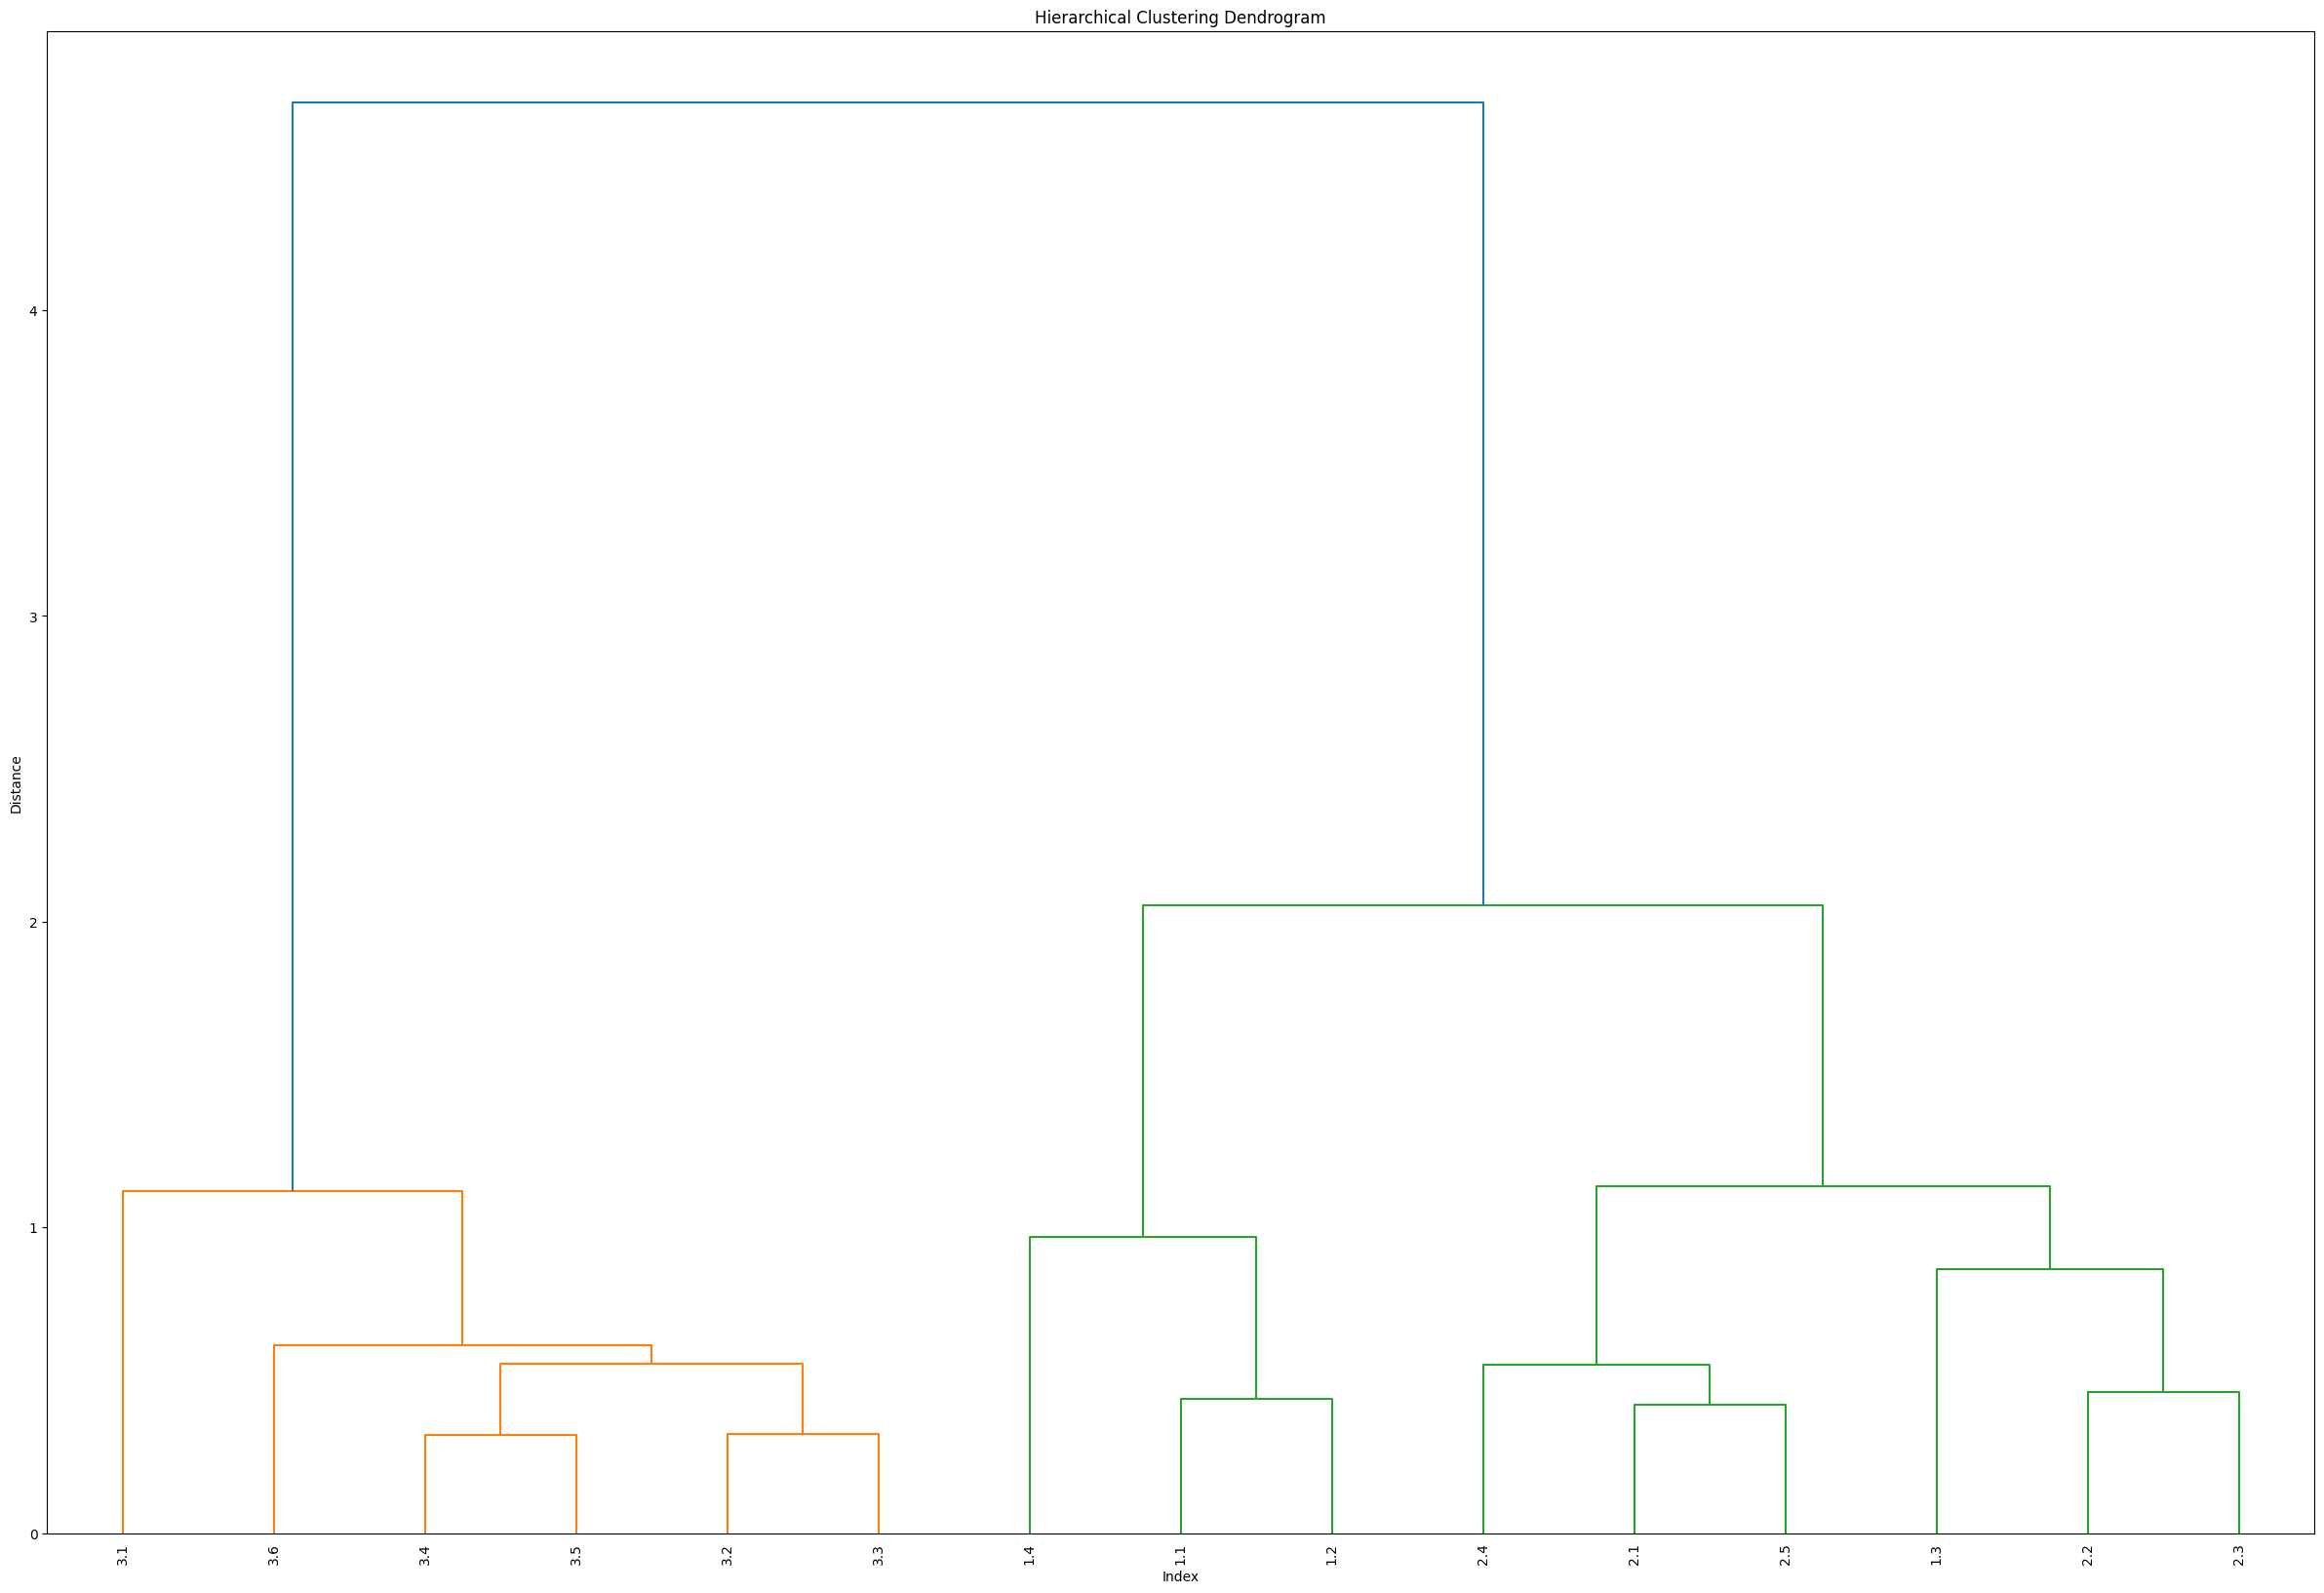

In [14]:
# Calculate the hierarchical matrix
linkage_matrix = sch.linkage(df_embeddings[['embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5']], method='ward')

plt.figure(figsize=(30, 20))
sch.dendrogram(linkage_matrix, labels=df_embeddings['skill_name'].values, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()


## 4.2) K-Means Clustering

### 4.2.1) Elbow-method


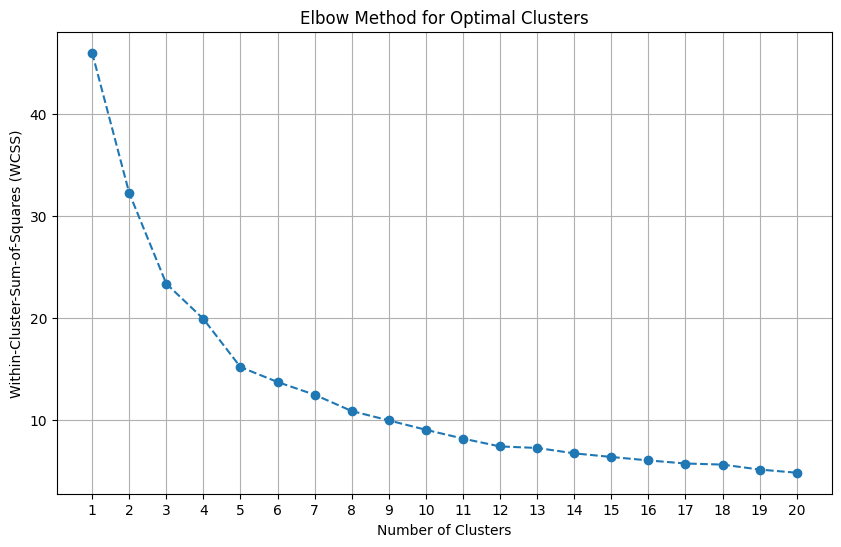

In [8]:
# Data preparation
data = df_embeddings[['embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5']]

wcss_list = []
range_n_clusters = range(1, 21)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(data)
    wcss_list.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, wcss_list, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster-Sum-of-Squares (WCSS)')
plt.xticks(range_n_clusters)
plt.grid()
plt.show()


The number of clusters should be 5.

In [15]:
data = df_embeddings[['embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5']]

n_clusters = 3

# KMeans clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_embeddings['cluster'] = kmeans.fit_predict(data)

for cluster in range(n_clusters):
    print(f"Cluster {cluster+1}:")
    skills = df_embeddings[df_embeddings['cluster'] == cluster]['skill_name'].tolist()
    print(skills)
    print("-" * 40)



Cluster 1:
[1.3, 2.1, 2.2, 2.3, 2.4, 2.5]
----------------------------------------
Cluster 2:
[3.1, 3.2, 3.3, 3.4, 3.5, 3.6]
----------------------------------------
Cluster 3:
[1.1, 1.2, 1.4]
----------------------------------------
